In [2]:
import csv

# criando os dados pro teste (com alguns erros propositais)
dados = [
    {"id": "1", "data": "2026-01-05", "cliente_id": "CLI001", "tipo": "credito", "valor": "3500.00", "descricao": "Salário", "categoria": "salario"},
    {"id": "2", "data": "2026-01-12", "cliente_id": "CLI002", "tipo": "debito", "valor": "180.50", "descricao": "Supermercado", "categoria": "compra"},
    {"id": "3", "data": "2026-02-14", "cliente_id": "CLI003", "tipo": "credito", "valor": "15000.00", "descricao": "Transf estranha", "categoria": "transferencia"},
    {"id": "4", "data": "2026-02-18", "cliente_id": "CLI002", "tipo": "debito", "valor": "320.00", "descricao": "Luz", "categoria": "conta"},
    {"id": "5", "data": "2026-03-01", "cliente_id": "CLI001", "tipo": "credito", "valor": "3500.00", "descricao": "Salário", "categoria": "salario"},
    {"id": "6", "data": "2026-03-10", "cliente_id": "CLI003", "tipo": "debito", "valor": "99.90", "descricao": "Netflix", "categoria": "assinatura"},
    {"id": "7", "data": "2026-04-05", "cliente_id": "CLI004", "tipo": "credito", "valor": "12500.00", "descricao": "Venda carro", "categoria": "venda"},
    {"id": "8", "data": "2026-04-12", "cliente_id": "CLI001", "tipo": "debito", "valor": "50.00", "descricao": "Padaria", "categoria": "compra"},
    # linhas com problemas pra testar os try/except
    {"id": "9", "data": "2026-01-20", "cliente_id": "CLI001", "tipo": "debito", "valor": "abc", "descricao": "erro de valor", "categoria": "compra"},
    {"id": "10", "data": "2026-02-03", "cliente_id": "", "tipo": "debito", "valor": "200.00", "descricao": "sem cliente", "categoria": "transferencia"},
    {"id": "X", "data": "2026-02-04", "cliente_id": "CLI005", "tipo": "debito", "valor": "100.00", "descricao": "id errado", "categoria": "compra"},
    {"id": "12", "data": "05-01-2026", "cliente_id": "CLI002", "tipo": "credito", "valor": "1000.00", "descricao": "data errada", "categoria": "venda"},
    {"id": "13", "data": "2026-05-10", "cliente_id": "CLI001", "tipo": "estorno", "valor": "500.00", "descricao": "tipo ruim", "categoria": "outros"}
]

colunas = ["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"]

# salva o arquivo
with open("transacoes.csv", "w", encoding="utf-8", newline="") as arquivo:
    escritor = csv.DictWriter(arquivo, fieldnames=colunas)
    escritor.writeheader()
    escritor.writerows(dados)

print("CSV de teste criado!")

CSV de teste criado!


In [4]:
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00

# formata pra reaisBR
def formata_rs(valor):
    texto = f"R$ {valor:,.2f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")

def validar_transacao(linha):
    # tenta converter, se der algum erro ignora a linha retornando None
    try:
        id_trans = int(linha["id"])

        if linha["cliente_id"].strip() == "":
            return None

        tipo = linha["tipo"]
        if tipo != "credito" and tipo != "debito":
            return None

        valor = float(linha["valor"])
        if valor <= 0:
            return None

        # ajusta a data
        data_formatada = datetime.strptime(linha["data"], "%Y-%m-%d")

        # se passou em tudo, devolve o dict limpo
        return {
            "id": id_trans,
            "data": data_formatada,
            "cliente_id": linha["cliente_id"],
            "tipo": tipo,
            "valor": valor,
            "descricao": linha.get("descricao", ""),
            "categoria": linha.get("categoria", "")
        }
    except ValueError:
        # print("erro de valor na linha", linha)
        return None
    except KeyError:
        return None

def ler_transacoes():
    validas = []
    lidas = 0
    invalidas = 0

    try:
        with open("transacoes.csv", "r", encoding="utf-8") as f:
            leitor = csv.DictReader(f)
            for linha in leitor:
                lidas += 1
                linha_limpa = validar_transacao(linha)

                if linha_limpa != None:
                    validas.append(linha_limpa)
                else:
                    invalidas += 1
    except FileNotFoundError:
        print("Arquivo transacoes.csv não existe na pasta!")

    return validas, lidas, invalidas

def gerar_relatorio(lista_transacoes):
    resumo = {}
    suspeitas = []

    if len(lista_transacoes) == 0:
        return {}, [], None, None

    primeira_data = lista_transacoes[0]["data"]
    ultima_data = lista_transacoes[0]["data"]

    for t in lista_transacoes:
        # checa datas
        if t["data"] < primeira_data:
            primeira_data = t["data"]
        if t["data"] > ultima_data:
            ultima_data = t["data"]

        mes = t["data"].strftime("%Y-%m")

        # cria o mes se nao existir no dic
        if mes not in resumo:
            resumo[mes] = {
                "quantidade": 0, "total_credito": 0.0, "total_debito": 0.0,
                "maior_valor": 0.0, "menor_valor": 999999.0
            }

        resumo[mes]["quantidade"] += 1

        if t["tipo"] == "credito":
            resumo[mes]["total_credito"] += t["valor"]
        elif t["tipo"] == "debito":
            resumo[mes]["total_debito"] += t["valor"]

        if t["valor"] > resumo[mes]["maior_valor"]:
            resumo[mes]["maior_valor"] = t["valor"]
        if t["valor"] < resumo[mes]["menor_valor"]:
            resumo[mes]["menor_valor"] = t["valor"]

        # verifica suspeitas
        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append({
                "id": t["id"], "cliente_id": t["cliente_id"],
                "data": t["data"].strftime("%Y-%m-%d"), "valor": t["valor"]
            })

    # calculando saldo e media no final do loop
    for m in resumo:
        resumo[m]["saldo"] = resumo[m]["total_credito"] - resumo[m]["total_debito"]
        resumo[m]["media"] = (resumo[m]["total_credito"] + resumo[m]["total_debito"]) / resumo[m]["quantidade"]

    return resumo, suspeitas, primeira_data, ultima_data

def salvar_json(resumo, lidas_ok, invalidas):
    dados_json = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": lidas_ok,
        "total_transacoes_invalidas": invalidas,
        "resumo_mensal": resumo
    }

    with open("relatorio.json", "w", encoding="utf-8") as f:
        json.dump(dados_json, f, ensure_ascii=False, indent=2)

def exibir_relatorio(resumo, suspeitas, lidas, validas, invalidas, d_ini, d_fim):
    print("===== RESUMO DA LEITURA =====")
    print(f"Total de linhas lidas: {lidas}")
    print(f"Linhas válidas: {validas}")
    print(f"Linhas inválidas: {invalidas}")

    if d_ini and d_fim:
        dias = (d_fim - d_ini).days
        print(f"Período analisado: {d_ini.strftime('%d/%m/%Y')} a {d_fim.strftime('%d/%m/%Y')} ({dias} dias)\n")

    # ordena por mes pra ficar bonito
    for mes in sorted(resumo.keys()):
        dados = resumo[mes]
        print(f"===== RELATÓRIO MENSAL =====")
        print(f"Mês: {mes}")
        print(f"  Transações: {dados['quantidade']}")
        print(f"  Total crédito: {formata_rs(dados['total_credito'])}")
        print(f"  Total débito:  {formata_rs(dados['total_debito'])}")
        print(f"  Saldo:         {formata_rs(dados['saldo'])}")
        print(f"  Média:         {formata_rs(dados['media'])}")
        print(f"  Maior valor:   {formata_rs(dados['maior_valor'])}")
        print(f"  Menor valor:   {formata_rs(dados['menor_valor'])}\n")

    print("===== TRANSAÇÕES SUSPEITAS =====")
    if len(suspeitas) > 0:
        for s in suspeitas:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | Data: {s['data']} | Valor: {formata_rs(s['valor'])}")
    else:
        print("Nenhuma transação suspeita encontrada.")

In [5]:
# Célula principal pra rodar tudo

transacoes_ok, total, erros = ler_transacoes()

if len(transacoes_ok) > 0:
    resumo_meses, lista_suspeitas, dt_ini, dt_fim = gerar_relatorio(transacoes_ok)

    exibir_relatorio(resumo_meses, lista_suspeitas, total, len(transacoes_ok), erros, dt_ini, dt_fim)

    salvar_json(resumo_meses, len(transacoes_ok), erros)
    print("\nArquivo relatorio.json salvo com sucesso!")
else:
    print("Não achou nenhuma transação válida...")

===== RESUMO DA LEITURA =====
Total de linhas lidas: 13
Linhas válidas: 8
Linhas inválidas: 5
Período analisado: 05/01/2026 a 12/04/2026 (97 dias)

===== RELATÓRIO MENSAL =====
Mês: 2026-01
  Transações: 2
  Total crédito: R$ 3.500,00
  Total débito:  R$ 180,50
  Saldo:         R$ 3.319,50
  Média:         R$ 1.840,25
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 180,50

===== RELATÓRIO MENSAL =====
Mês: 2026-02
  Transações: 2
  Total crédito: R$ 15.000,00
  Total débito:  R$ 320,00
  Saldo:         R$ 14.680,00
  Média:         R$ 7.660,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 320,00

===== RELATÓRIO MENSAL =====
Mês: 2026-03
  Transações: 2
  Total crédito: R$ 3.500,00
  Total débito:  R$ 99,90
  Saldo:         R$ 3.400,10
  Média:         R$ 1.799,95
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

===== RELATÓRIO MENSAL =====
Mês: 2026-04
  Transações: 2
  Total crédito: R$ 12.500,00
  Total débito:  R$ 50,00
  Saldo:         R$ 12.450,00
  Média:         R$ 

grafico.png salvo!


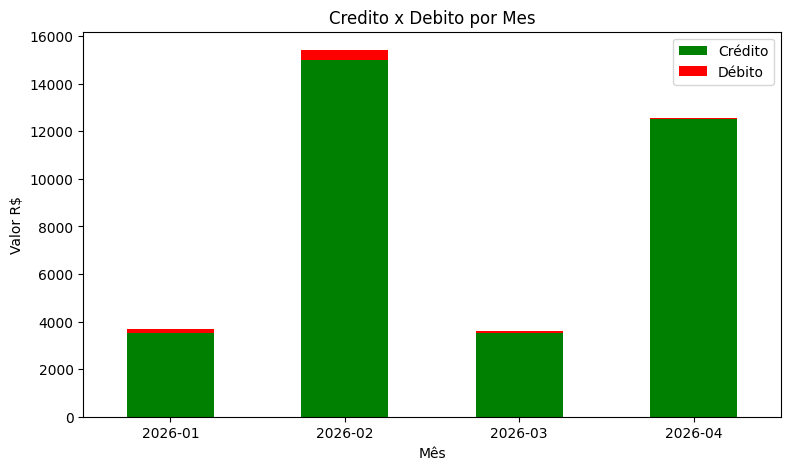

In [6]:
# Requisitos extras
import pandas as pd
import matplotlib.pyplot as plt

try:
    # lendo arquivo
    df = pd.read_csv("transacoes.csv")

    # limpando dados parecidos com a nossa regra
    df = df.dropna(subset=['id', 'cliente_id', 'data', 'tipo', 'valor'])
    df = df[df['tipo'].isin(['credito', 'debito'])]

    # arruma valor e data
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df = df[df['valor'] > 0]
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['data'])

    # extrai so o mes
    df['mes'] = df['data'].dt.strftime('%Y-%m')

    # agrupa por mes e tipo pra gerar as colunas de credito e debito
    df_agrupado = df.groupby(['mes', 'tipo'])['valor'].sum().unstack(fill_value=0)

    # plota
    df_agrupado.plot(kind='bar', stacked=True, figsize=(9, 5), color=['green', 'red'])
    plt.title('Credito x Debito por Mes')
    plt.xlabel('Mês')
    plt.ylabel('Valor R$')
    plt.legend(['Crédito', 'Débito'])
    plt.xticks(rotation=0)

    plt.savefig('grafico.png')
    print("grafico.png salvo!")
    plt.show()

except Exception as erro:
    print("Deu um erro no pandas/plot:", erro)